# Land Use Classification from Satellite Images  

Group 4: Teresa Alvarez, Vikram Bhatt, Alessandro Cristofolini, Matteo Khoueiri, Dominique Robson, & Pengchong Zhao

---

## Executive Summary

In this project, we address the problem of land use classification using satellite image patches from the EuroSAT RGB dataset. The objective is to automatically classify land cover types (e.g., Forest, Residential, River, Industrial) from aerial imagery.

We compare two approaches:

1. A classical computer vision baseline using HOG features and a linear SVM.
2. A deep learning approach using transfer learning with a pretrained Convolutional Neural Network (CNN).


----
# 1. Business / Research Question

## Problem

Can satellite image patches be automatically classified into land use categories to support environmental monitoring and urban planning?

## Motivation

Manual annotation of satellite imagery is costly and time-consuming. Automated classification can:

- Accelerate large-scale analysis
- Support planning and monitoring
- Flag uncertain cases for human review

The system is intended as decision support rather than full automation.

In [1]:
from pathlib import Path
import random
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# 2. Dataset

## 2.1 Source

We use the EuroSAT RGB dataset:

- ~27,000 satellite image patches
- 10 land use classes
- RGB format, 64×64 resolution
- Images organized in class-based folders

## 2.2 Classes

- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake

Each image represents a satellite patch labeled with its dominant land use type.

In [2]:
DATA_DIR = Path("img")

# Verificar que existe
if not DATA_DIR.exists():
    raise FileNotFoundError(f"{DATA_DIR} not found")

# Detectar clases (subcarpetas)
classes = sorted([folder.name for folder in DATA_DIR.iterdir() if folder.is_dir()])

print(f"Number of classes detected: {len(classes)}")
print("Classes:")
for c in classes:
    print("-", c)

Number of classes detected: 10
Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [3]:
image_extensions = {".jpg", ".jpeg", ".png"}

data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    data.append({
        "class": cls,
        "num_images": len(images)
    })

df_counts = pd.DataFrame(data).sort_values("class")
total_images = df_counts["num_images"].sum()

print(df_counts)
print("\nTotal images:", total_images)

                  class  num_images
0            AnnualCrop        3000
1                Forest        3000
2  HerbaceousVegetation        3000
3               Highway        2500
4            Industrial        2500
5               Pasture        2000
6         PermanentCrop        2500
7           Residential        3000
8                 River        2500
9               SeaLake        3000

Total images: 27000


## 2.3 Visualization of classes

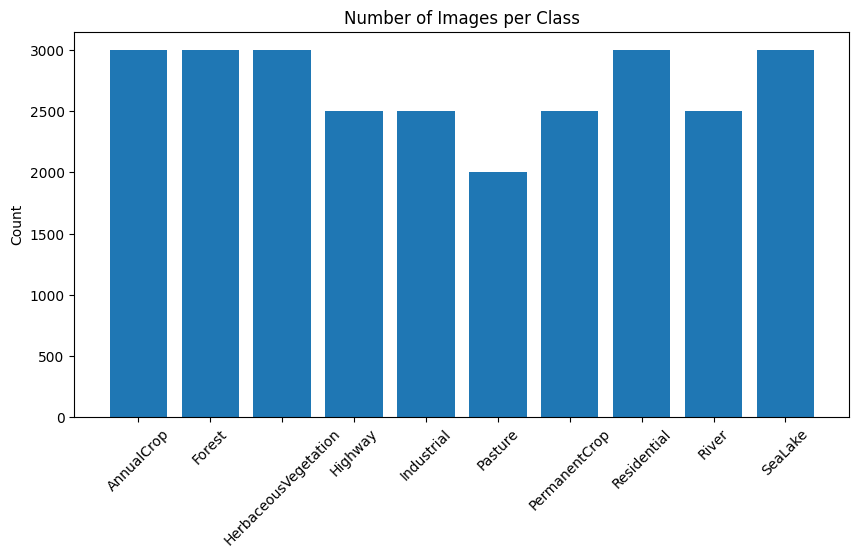

In [4]:
plt.figure(figsize=(10,5))
plt.bar(df_counts["class"], df_counts["num_images"])
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.ylabel("Count")
plt.show()

## 2.4 Corrupted image check

No images are corrupter out of the 27000

In [5]:
corrupted = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    sample_images = random.sample(images, min(200, len(images)))
    
    for img_path in sample_images:
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)

print("Number of corrupted images found:", len(corrupted))

Number of corrupted images found: 0


## 2.5 Dataset Indexing

To prepare the dataset for model training, we construct a master DataFrame containing:

- The image file path
- The corresponding class label

This structured representation will allow us to perform a reproducible train/validation/test split while ensuring consistency across models.

In [10]:
all_data = []

for cls in classes:
    class_path = DATA_DIR / cls
    images = [f for f in class_path.iterdir() if f.suffix.lower() in image_extensions]
    
    for img_path in images:
        all_data.append({
            "path": str(img_path),
            "label": cls
        })

df_all = pd.DataFrame(all_data)

print("Total images indexed:", len(df_all))
df_all.head()

#guardar dataframe por si acaso
df_all.to_csv("csv/image_data.csv", index=False)

Total images indexed: 27000


In [8]:
df_all["label"].value_counts()

label
AnnualCrop              3000
Forest                  3000
HerbaceousVegetation    3000
Residential             3000
SeaLake                 3000
Highway                 2500
Industrial              2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64